# Phase 6: Modelling and Hyperparameter Optimization

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer

# Configure Plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)





## 1. Load the Fully Engineered ML Dataset

In [2]:
processed_dir = Path("../data/processed")
features_path = processed_dir / "final_ml_features.parquet"

df = pd.read_parquet(features_path)

# Drop any NaN rows generated from the lagging/rolling logic (the first 168 hours will be NaN due to the t-168 weekly lag)
df = df.dropna()

print(f"Dataset shape after dropping Nulls: {df.shape}")
df.head(3)

Dataset shape after dropping Nulls: (10009, 35)


,total_demand,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_6,rolling_std_6,rolling_max_6,...,ewma_span_72,hour,day_of_week,is_weekend,day_of_month,month,quarter,hour_sin,hour_cos,is_holiday
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:00,1079,2219.0,3740.0,5834.0,1042.0,1051.0,6610.0,5106.500000,1808.302381,7272.0,...,3867.045281,0,2,0,8,1,1,0.000000,1.000000,0
2025-01-08 01:00:00,382,1079.0,2219.0,3740.0,423.0,437.0,7481.0,4074.333333,2073.110963,5834.0,...,3790.660479,1,2,0,8,1,1,0.258819,0.965926,0
2025-01-08 02:00:00,200,382.0,1079.0,2219.0,242.0,231.0,6126.0,3173.666667,2337.745296,5834.0,...,3697.272521,2,2,0,8,1,1,0.500000,0.866025,0


## 2. Train / Test Split

In [3]:
# Sort the dataset chronologically just in case
df.sort_index(inplace=True)

# Determine the index cutoff
train_size = int(len(df) * 0.9)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# The target variable is 'total_demand'. However, 'holiday_name' is categorical text. We will drop text columns.
DROP_COLS = ['total_demand']
FEATURE_COLS = [col for col in train_df.columns if col not in DROP_COLS]

X_train = train_df[FEATURE_COLS]
y_train = train_df['total_demand']

X_test = test_df[FEATURE_COLS]
y_test = test_df['total_demand']

X_train.to_parquet("../data/processed/X_train.parquet")
X_test.to_parquet("../data/processed/X_test.parquet")
y_train.to_frame().to_parquet("../data/processed/y_train.parquet")
y_test.to_frame().to_parquet("../data/processed/y_test.parquet")

print(f"Training Set: X={X_train.shape}, y={y_train.shape}")
print(f"Holdout Test Set: X={X_test.shape}, y={y_test.shape}")

Training Set: X=(9008, 34), y=(9008,)
Holdout Test Set: X=(1001, 34), y=(1001,)


## 3. Modeling Pipeline Construction

In [4]:
tscv = TimeSeriesSplit(n_splits=10)

# Evaluation Metric: MAE (Mean Absolute Error) is less sensitive to extreme anomaly spikes than RMSE.
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

def build_pipeline(model):
    """Utility function to wrap a model in standard preprocessing."""
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures()),
        ('reg', model)
    ])

## 4. Hyperparameter Optimization: Regularized Models

In [5]:
# 1. Ridge Regression Optimization
ridge_pipe = build_pipeline(Ridge(random_state=42))

ridge_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.1, 1.0, 10.0]
}

print("Starting Ridge GridSearch...")
ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=3
)

ridge_search.fit(X_train, y_train)
print(f"Best Ridge Params: {ridge_search.best_params_}")
print(f"Best Ridge CV MAE: {-ridge_search.best_score_:.4f}")

Starting Ridge GridSearch...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Best Ridge Params: {'poly__degree': 1, 'reg__alpha': 0.1}
Best Ridge CV MAE: 383.0960


In [6]:
# 2. Lasso Regression Optimization
lasso_pipe = build_pipeline(Lasso(random_state=42, max_iter=2000))

# Lasso natively drops weak features to 0
lasso_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.01, 0.1, 1.0, 10.0, 20.0, 50.0]
}

print("Starting Lasso GridSearch...")
lasso_search = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=lasso_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train, y_train)
print(f"Best Lasso Params: {lasso_search.best_params_}")
print(f"Best Lasso CV MAE: {-lasso_search.best_score_:.4f}")

Starting Lasso GridSearch...
Fitting 10 folds for each of 18 candidates, totalling 180 fits
Best Lasso Params: {'poly__degree': 2, 'reg__alpha': 10.0}
Best Lasso CV MAE: 356.6218


In [7]:
# 3. ElasticNet Regression Optimization
elasticnet_pipe = build_pipeline(ElasticNet(random_state=42, max_iter=2000))

elasticnet_param_grid = {
    'poly__degree': [1, 2, 3],
    'reg__alpha': [0.01, 0.025, 0.05, 0.1, 1.0],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

print("Starting ElasticNet GridSearch...")
elasticnet_search = GridSearchCV(
    estimator=elasticnet_pipe,
    param_grid=elasticnet_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=1
)

elasticnet_search.fit(X_train, y_train)
print(f"Best ElasticNet Params: {elasticnet_search.best_params_}")
print(f"Best ElasticNet CV MAE: {-elasticnet_search.best_score_:.4f}")

Starting ElasticNet GridSearch...
Fitting 10 folds for each of 45 candidates, totalling 450 fits
Best ElasticNet Params: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__l1_ratio': 0.8}
Best ElasticNet CV MAE: 391.9003


## 5. Hyperparameter Optimization: SGDRegressor

In [8]:
sgd_pipe = build_pipeline(SGDRegressor(random_state=42))

sgd_param_grid = {
    'poly__degree': [1, 2],
    'reg__penalty': ['l2', 'l1', 'elasticnet'],
    'reg__alpha': [0.001, 0.01],
    'reg__learning_rate': ['invscaling', 'adaptive'],
}

print("Starting SGDRegressor GridSearch...")
sgd_search = GridSearchCV(
    estimator=sgd_pipe,
    param_grid=sgd_param_grid,
    cv=tscv,
    scoring=scorer,
    n_jobs=-1,
    verbose=3
)


sgd_search.fit(X_train, y_train)
print(f"Best SGD Params: {sgd_search.best_params_}")
print(f"Best SGD CV MAE: {-sgd_search.best_score_:.4f}")

Starting SGDRegressor GridSearch...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
Best SGD Params: {'poly__degree': 1, 'reg__alpha': 0.01, 'reg__learning_rate': 'adaptive', 'reg__penalty': 'l1'}
Best SGD CV MAE: 387.1485


## 6. Cross-Validation Results Summary

In [41]:
from scipy import stats as scipy_stats

n_splits = 10
searches = {
    'Ridge': ridge_search,
    'Lasso': lasso_search,
    'ElasticNet': elasticnet_search,
    'SGDRegressor': sgd_search,
}

summary_rows = []
fold_data = {}

for name, search in searches.items():
    best_idx = search.best_index_
    fold_maes = np.array([
        -search.cv_results_[f'split{i}_test_score'][best_idx]
        for i in range(n_splits)
    ])
    fold_data[name] = fold_maes
    summary_rows.append({
        'Model': name,
        'Mean MAE': np.mean(fold_maes),
        'Std MAE': np.std(fold_maes, ddof=1),
        'Min MAE': np.min(fold_maes),
        'Median MAE': np.median(fold_maes),
        'Max MAE': np.max(fold_maes),
    })

cv_df = pd.DataFrame(summary_rows).set_index('Model')

PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
model_names = cv_df.index.tolist()
model_color_map = dict(zip(model_names, PALETTE))

# ── Styling helpers ──────────────────────────────────────────────────────────
def _force_text(_):
    # Wins against dark notebook themes regardless of cell background
    return 'color: #2c3e50; font-weight: 600'

_header = [
    ('background-color', '#2c3e50'), ('color', 'white'),
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '10px 16px'), ('font-weight', 'bold'),
]
_cell = [
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '9px 16px'),
    ('border-bottom', '1px solid #eaecee'),
    ('background-color', 'white'),     # defeat dark-theme bleed-through
    ('color', '#2c3e50'),
]
_row_heading = _cell + [('font-weight', 'bold'), ('text-align', 'right')]
_caption = [
    ('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2c3e50'),
    ('padding-bottom', '10px'), ('text-align', 'left'),
]

# Use a shared range for the spread columns so the bars are comparable
spread_cols = ['Min MAE', 'Median MAE', 'Max MAE']
spread_min  = cv_df[spread_cols].values.min()
spread_max  = cv_df[spread_cols].values.max()

display(
    cv_df.style

    .bar(subset=spread_cols,
         color='#5dade2',
         vmin=spread_min, vmax=spread_max,
         height=70, width=92, align='left')
    .map(_force_text, subset=cv_df.columns.tolist())
    .format('{:.2f}')
    .set_caption('Cross-Validation Summary | Best Config per Model')
    .set_table_styles([
        {'selector': 'thead th',       'props': _header},
        {'selector': 'td',             'props': _cell},
        {'selector': 'th.row_heading', 'props': _row_heading},
        {'selector': 'th.blank',       'props': [('background-color', 'white')]},
        {'selector': 'caption',        'props': _caption},
        {'selector': 'table', 'props': [
            ('border-collapse', 'separate'), ('border-spacing', '0'),
            ('background-color', 'white'),
        ]},
    ])
)

,Mean MAE,Std MAE,Min MAE,Median MAE,Max MAE
Model,,,,,
Ridge,383.10,52.53,274.23,386.65,466.29
Lasso,356.62,61.68,259.01,353.09,495.84
ElasticNet,391.90,54.98,277.21,394.43,475.63
SGDRegressor,387.15,56.55,275.29,389.04,488.16


## 7. Advanced Model Selection Techniques

| # | Method | Formul |
|---|--------|--------|
| 0 | **Classic** | argmin E[MAE] |
| 1 | **Penalized Mean (λ=1)** | E[MAE] + λ·σ |
| 2 | **One Standard Error Rule** | Most stabil model: M∗ ± SE |
| 3 | **Coefficient of Variation** | E[MAE]·(1 + σ/E[MAE]) |
| 4 | **Upper Confidence Bound** | E[MAE] + 1.96·σ/√n |
| 5 | **CVaR (worst 20%)** | avg(worst 2 fold) |
| 6 | **Z-Score Combined** | z(mean) + z(std) |

In [20]:
# 0. Classic
classic_winner = cv_df['Mean MAE'].idxmin()

# 1. Penalized Mean (lambda = 1)
cv_df['Penalized_L1'] = cv_df['Mean MAE'] + 1.0 * cv_df['Std MAE']
penalized_winner = cv_df['Penalized_L1'].idxmin()

# 2. One Standard Error Rule
se_best = cv_df.loc[classic_winner, 'Std MAE'] / np.sqrt(n_splits)
threshold_1se = cv_df['Mean MAE'].min() + se_best
eligible_1se = cv_df[cv_df['Mean MAE'] <= threshold_1se]
one_se_winner = eligible_1se['Std MAE'].idxmin()

# 3. Coefficient of Variation  (mean*(1+CV) = mean+std, scale-independent)
cv_df['CV_Score'] = cv_df['Mean MAE'] * (1 + cv_df['Std MAE'] / cv_df['Mean MAE'])
cv_score_winner = cv_df['CV_Score'].idxmin()

# 4. Upper Confidence Bound (k = 1.96, 95%)
cv_df['UCB_95'] = cv_df['Mean MAE'] + 1.96 * cv_df['Std MAE'] / np.sqrt(n_splits)
ucb_winner = cv_df['UCB_95'].idxmin()

# 5. CVaR — worst 20% of folds
n_worst = max(1, int(np.ceil(n_splits * 0.20)))
cvar_vals = {
    name: np.mean(sorted(maes, reverse=True)[:n_worst])
    for name, maes in fold_data.items()
}
cv_df['CVaR_20pct'] = pd.Series(cvar_vals)
cvar_winner = cv_df['CVaR_20pct'].idxmin()

# 6. Z-Score Combined
cv_df['ZScore_Combined'] = (
    scipy_stats.zscore(cv_df['Mean MAE'].values)
    + scipy_stats.zscore(cv_df['Std MAE'].values)
)
zscore_winner = cv_df['ZScore_Combined'].idxmin()

technique_map = {
    'Classic':               classic_winner,
    'Penalized Mean (L=1)':  penalized_winner,
    'One SE Rule':           one_se_winner,
    'CV Score':              cv_score_winner,
    'UCB (95%)':             ucb_winner,
    'CVaR (20%)':            cvar_winner,
    'Z-Score Combined':      zscore_winner,
}

vote_counts = pd.Series(technique_map.values()).value_counts()

sel_df = pd.DataFrame({
    'Selected Model':  list(technique_map.values()),
    'Criterion Score': [
        cv_df.loc[classic_winner,   'Mean MAE'],
        cv_df.loc[penalized_winner, 'Penalized_L1'],
        cv_df.loc[one_se_winner,    'Std MAE'],
        cv_df.loc[cv_score_winner,  'CV_Score'],
        cv_df.loc[ucb_winner,       'UCB_95'],
        cv_df.loc[cvar_winner,      'CVaR_20pct'],
        cv_df.loc[zscore_winner,    'ZScore_Combined'],
    ],
    'CV Mean MAE': [cv_df.loc[technique_map[t], 'Mean MAE'] for t in technique_map],
    'CV Std MAE':  [cv_df.loc[technique_map[t], 'Std MAE']  for t in technique_map],
    'Votes':       [vote_counts.get(technique_map[t], 0)     for t in technique_map],
}, index=pd.Index(list(technique_map.keys()), name='Technique'))

def _model_badge(val):
    c = model_color_map.get(val, '#888')
    return (f'background-color: {c}22; color: {c}; '
            f'font-weight: bold; border-left: 3px solid {c}')

_header = [
    ('background-color', '#2c3e50'), ('color', 'white'),
    ('font-size', '13px'), ('text-align', 'center'), ('padding', '10px 14px'),
]
_cell = [
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '8px 14px'), ('border-bottom', '1px solid #eaecee'),
]

display(
    sel_df.style
    .map(_model_badge, subset=['Selected Model'])
    .background_gradient(subset=['CV Mean MAE'], cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['CV Std MAE'],  cmap='YlOrRd',   axis=0)
    .background_gradient(subset=['Votes'],        cmap='Blues',    axis=0)
    .format({'Criterion Score': '{:.3f}', 'CV Mean MAE': '{:.2f}',
             'CV Std MAE': '{:.2f}', 'Votes': '{:.0f}'})
    .set_caption('Model Selection Results by Technique  |  Votes = number of techniques selecting that model')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2c3e50'),
            ('padding-bottom', '10px'), ('text-align', 'left'),
        ]},
    ])
)

,Selected Model,Criterion Score,CV Mean MAE,CV Std MAE,Votes
Technique,,,,,
Classic,Lasso,356.622,356.62,61.68,5
Penalized Mean (L=1),Lasso,418.301,356.62,61.68,5
One SE Rule,Lasso,61.680,356.62,61.68,5
CV Score,Lasso,418.301,356.62,61.68,5
UCB (95%),Lasso,394.851,356.62,61.68,5
CVaR (20%),Ridge,442.594,383.10,52.53,2
Z-Score Combined,Ridge,-0.918,383.10,52.53,2


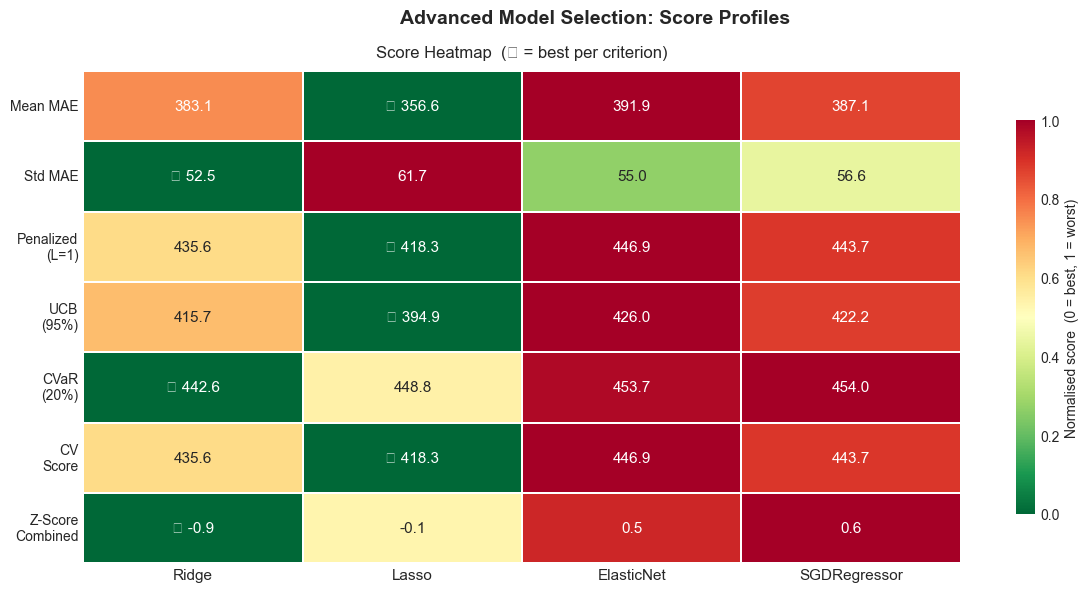

In [30]:
score_cols   = ['Mean MAE', 'Std MAE', 'Penalized_L1', 'UCB_95', 'CVaR_20pct',
                'CV_Score', 'ZScore_Combined']
score_labels = ['Mean MAE', 'Std MAE', 'Penalized\n(L=1)', 'UCB\n(95%)',
                'CVaR\n(20%)', 'CV\nScore', 'Z-Score\nCombined']

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.suptitle('Advanced Model Selection: Score Profiles',
             fontsize=14, fontweight='bold')

# ── Normalised heatmap — annotations show actual values + ★ for column best ──
heat_data = cv_df[score_cols].copy()
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

annot = heat_data.round(1).astype(str)
for col in score_cols:
    annot.loc[heat_data[col].idxmin(), col] = '★ ' + annot.loc[heat_data[col].idxmin(), col]

sns.heatmap(
    heat_norm.T,
    annot=annot.T, fmt='s',
    cmap='RdYlGn_r', ax=ax,
    linewidths=1.2, linecolor='white',
    yticklabels=score_labels,
    cbar_kws={'label': 'Normalised score  (0 = best, 1 = worst)', 'shrink': 0.8},
    annot_kws={'size': 11},
)
ax.set_title('Score Heatmap  (★ = best per criterion)', fontsize=12, pad=10)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0, labelsize=11)
ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/model_selection_techniques.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test Set Evaluation: Classical vs Advanced Selection

In [24]:
def compute_test_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    safe = np.where(np.abs(y_true) < 1, np.nan, y_true)
    mape = np.nanmean(np.abs((y_true - y_pred) / safe)) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

model_estimators = {
    'Ridge':        ridge_search.best_estimator_,
    'Lasso':        lasso_search.best_estimator_,
    'ElasticNet':   elasticnet_search.best_estimator_,
    'SGDRegressor': sgd_search.best_estimator_,
}

test_metrics_all = {}
test_preds       = {}

for name, est in model_estimators.items():
    y_pred = est.predict(X_test)
    test_preds[name]       = y_pred
    test_metrics_all[name] = compute_test_metrics(y_test.values, y_pred)

test_results = pd.DataFrame(test_metrics_all).T
test_results.index.name = 'Model'

_header = [
    ('background-color', '#2c3e50'), ('color', 'white'),
    ('font-size', '13px'), ('text-align', 'center'), ('padding', '10px 18px'),
]
_cell = [
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '9px 18px'), ('border-bottom', '1px solid #eaecee'),
]

display(
    test_results.style
    .background_gradient(subset=['MAE'],      cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['RMSE'],     cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['MAPE (%)'], cmap='RdYlGn_r', axis=0)
    .format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'MAPE (%)': '{:.2f}%'})
    .set_caption('Test Set Performance — All Models  |  Green = best, Red = worst per metric')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2c3e50'),
            ('padding-bottom', '10px'), ('text-align', 'left'),
        ]},
    ])
)

,MAE,RMSE,MAPE (%)
Model,,,
Ridge,443.83,648.02,289.97%
Lasso,386.72,595.93,291.66%
ElasticNet,453.56,664.52,287.03%
SGDRegressor,444.08,647.91,288.71%


In [33]:
comparison_rows = []
for tech, model in technique_map.items():
    row = {'Technique': tech, 'Selected Model': model}
    row.update({k: v for k, v in test_metrics_all[model].items()})
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Technique')
classic_mae_val = comparison_df.loc['Classic', 'MAE']
comparison_df['Delta MAE'] = comparison_df['MAE'] - classic_mae_val

def _delta_style(val):
    if val < -0.5:
        return 'background-color: #d5f5e3; color: #1a7a4a; font-weight: bold'
    if val > 0.5:
        return 'background-color: #fde8e8; color: #c0392b; font-weight: bold'
    return 'color: #7f8c8d'

def _fmt_delta(val):
    return f'+{val:.2f}' if val > 0 else f'{val:.2f}'

_header = [
    ('background-color', '#2c3e50'), ('color', 'white'),
    ('font-size', '13px'), ('text-align', 'center'), ('padding', '10px 14px'),
]
_cell = [
    ('font-size', '13px'), ('text-align', 'center'),
    ('padding', '8px 14px'), ('border-bottom', '1px solid #eaecee'),
]

display(
    comparison_df.style
    .map(_model_badge, subset=['Selected Model'])
    .map(_delta_style,  subset=['Delta MAE'])
    .background_gradient(subset=['MAE'],      cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['RMSE'],     cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['MAPE (%)'], cmap='RdYlGn_r', axis=0)
    .format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'MAPE (%)': '{:.2f}%',
             'Delta MAE': _fmt_delta})
    .set_caption('Test Set Performance by Technique  |  Delta MAE = difference vs Classic baseline')
    .set_table_styles([
        {'selector': 'thead th', 'props': _header},
        {'selector': 'td',       'props': _cell},
        {'selector': 'caption',  'props': [
            ('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2c3e50'),
            ('padding-bottom', '10px'), ('text-align', 'left'),
        ]},
    ])
)

,Selected Model,MAE,RMSE,MAPE (%),Delta MAE
Technique,,,,,
Classic,Lasso,386.72,595.93,291.66%,0.00
Penalized Mean (L=1),Lasso,386.72,595.93,291.66%,0.00
One SE Rule,Lasso,386.72,595.93,291.66%,0.00
CV Score,Lasso,386.72,595.93,291.66%,0.00
UCB (95%),Lasso,386.72,595.93,291.66%,0.00
CVaR (20%),Ridge,443.83,648.02,289.97%,+57.11
Z-Score Combined,Ridge,443.83,648.02,289.97%,+57.11


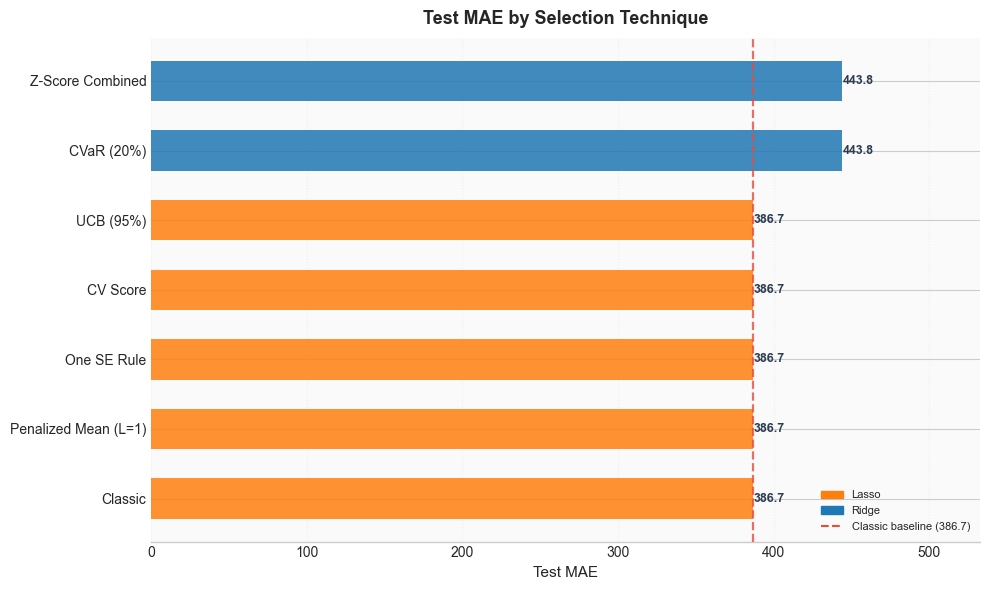

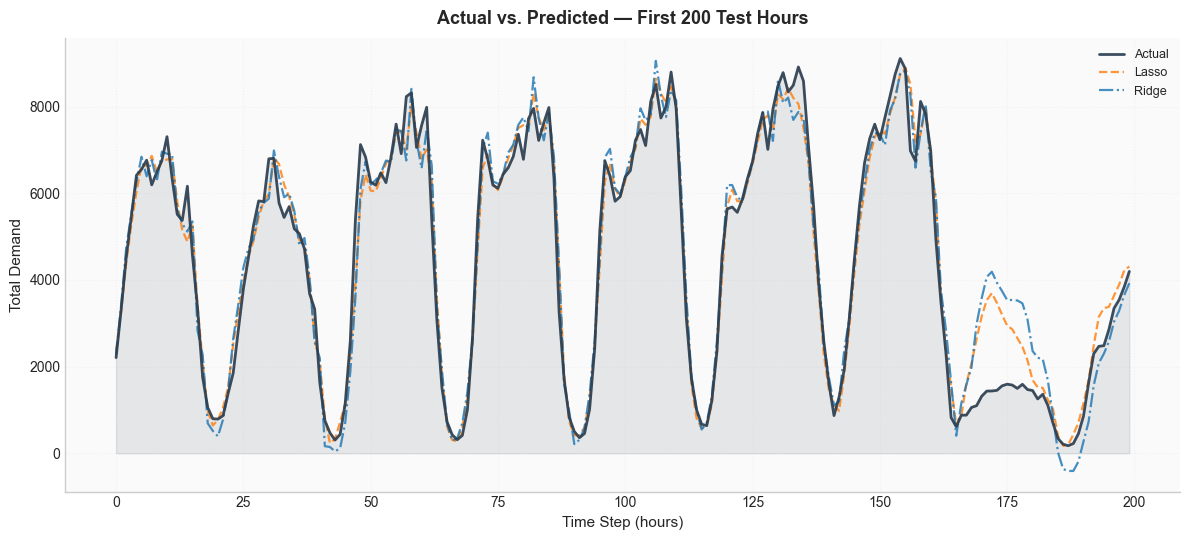

In [31]:
from matplotlib.patches import Patch
import matplotlib.lines as mlines

unique_models = list(dict.fromkeys(technique_map.values()))
tech_names    = list(technique_map.keys())
bar_colors    = [model_color_map[technique_map[t]] for t in tech_names]

classic_mae_test = test_metrics_all[classic_winner]['MAE']
y_pos = list(range(len(tech_names)))

# ── Figure 1: Test MAE by Selection Technique ────────────────────────────────
fig, ax0 = plt.subplots(figsize=(10, 6))
bars = ax0.barh(y_pos, [test_metrics_all[technique_map[t]]['MAE'] for t in tech_names],
                color=bar_colors, alpha=0.85, edgecolor='none', height=0.58)
ax0.set_yticks(y_pos)
ax0.set_yticklabels(tech_names, fontsize=10)
ax0.set_xlabel('Test MAE', fontsize=11)
ax0.set_title('Test MAE by Selection Technique', fontsize=13, fontweight='bold', pad=10)
ax0.spines[['top', 'right', 'left']].set_visible(False)
ax0.tick_params(left=False)
ax0.grid(axis='x', alpha=0.25, linestyle=':')
ax0.axvline(classic_mae_test, color='#e74c3c', linestyle='--',
            linewidth=1.6, alpha=0.8, zorder=3)
for bar in bars:
    v = bar.get_width()
    ax0.text(v + 0.4, bar.get_y() + bar.get_height() / 2,
             f'{v:.1f}', va='center', ha='left', fontsize=9, fontweight='bold', color='#2c3e50')
legend_handles  = [Patch(color=model_color_map[m], label=m) for m in unique_models]
legend_handles += [mlines.Line2D([], [], color='#e74c3c', linestyle='--',
                                 label=f'Classic baseline ({classic_mae_test:.1f})')]
ax0.legend(handles=legend_handles, fontsize=8, loc='lower right', framealpha=0.9)
ax0.set_xlim(0, max(test_metrics_all[technique_map[t]]['MAE'] for t in tech_names) * 1.20)
ax0.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('../reports/figures/test_mae_by_technique.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: Actual vs Predicted — first 200 test hours ─────────────────────
fig, ax2 = plt.subplots(figsize=(12, 5.5))
x_range = np.arange(200)
ax2.fill_between(x_range, y_test.values[:200],
                 alpha=0.10, color='#2c3e50')
ax2.plot(x_range, y_test.values[:200], color='#2c3e50',
         linewidth=2.0, label='Actual', alpha=0.92, zorder=5)
ls_cycle = ['--', '-.', ':', (0, (3, 1, 1, 1))]
for mname, ls in zip(unique_models, ls_cycle):
    ax2.plot(x_range, test_preds[mname][:200],
             linewidth=1.6, alpha=0.82, linestyle=ls,
             color=model_color_map[mname], label=mname, zorder=4)
ax2.set_title('Actual vs. Predicted — First 200 Test Hours',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Time Step (hours)', fontsize=11)
ax2.set_ylabel('Total Demand', fontsize=11)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(alpha=0.2, linestyle=':')
ax2.set_facecolor('#fafafa')

plt.tight_layout()
plt.savefig('../reports/figures/actual_vs_predicted_test.png', dpi=150, bbox_inches='tight')
plt.show()